## Import Libraries

In [1]:
import os
import re
import requests
import pandas as pd
import numpy as np
import spacy
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from bs4 import BeautifulSoup
from pathlib import Path
from typing import List, Dict, Tuple
from collections import Counter

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Download the books and clean the data

In [2]:
base_url = "https://www.gutenberg.org/files/"
books = {"pride_and_prejudice": {"id": 1342, "author": "Jane Austen"},
            "alice_wonderland": {"id": 11, "author": "Lewis Carroll"},
            "sherlock_holmes": {"id": 1661, "author": "Arthur Conan Doyle"},
            "great_expectations": {"id": 1400, "author": "Charles Dickens"},
            "dorian_gray": {"id": 174, "author": "Oscar Wilde"},
            "frankenstein": {"id": 84, "author": "Mary Shelley"},
            "time_machine": {"id": 35, "author": "H.G. Wells"},
            "monte_cristo": {"id": 1184, "author": "Alexandre Dumas"},
            "dracula": {"id": 345, "author": "Bram Stoker"},
            "tom_sawyer": {"id": 74, "author": "Mark Twain"}}

In [3]:
def download_text(book_id:str, filename:str, save_path:str) -> str:
    """Download the books from the link provided and save in the folder"""
    url = f"{base_url}/{book_id}/{book_id}-0.txt"
    try:
        response = requests.get(url)
        response.raise_for_status()
        response.encoding = "utf-8"

        if response.status_code == 200:
            os.makedirs(save_path, exist_ok=True)
            full_path = os.path.join(save_path, filename)
            with open(full_path, 'w', encoding='utf-8') as f:
                f.write(response.text)
                print(f"Successfully downloaded book {book_id} to {full_path}") 

            return response.text

    except requests.RequestException as e:
        print(f"Error downloading {book_id}: {e}")
        return None    

In [ ]:
base_directory = "data/books"
for name, details in books.items():
    book_id = str(details["id"])
    author = details["author"]
    name_book = author +" "+ name + ".txt"
    download_text(book_id=book_id, filename=name_book, save_path=base_directory)

In [4]:
def clean_text(text:str)-> str:
    start_maker =  r'\*\*\* START OF (THE |THIS )?PROJECT GUTENBERG EBOOK.*?\*\*\*'
    start_match = re.search(start_maker, text, re.IGNORECASE | re.DOTALL)
    end_maker = r'\*\*\* END OF (THE |THIS )?PROJECT GUTENBERG EBOOK.*?\*\*\*'
    end_match = re.search(end_maker, text, re.IGNORECASE | re.DOTALL)


    if start_maker:
        text = text[start_match.end():]
    
    if end_match:
        text = text[:end_match.start()]

    return text.strip()

In [5]:
import os

directory_files = os.listdir("data/books")
data_cleaned = "data/data_cleaned"
os.makedirs(data_cleaned, exist_ok=True)
initial_corpus = {}

for file in directory_files:
    input_file_path = os.path.join("data/books", file)
    output_file_path = os.path.join(data_cleaned, file)

    with open(input_file_path, 'r', encoding='utf-8') as f:
        raw_text = f.read()
        cleaned_text = clean_text(raw_text)

    with open(output_file_path, "w", encoding='utf-8') as file_cleaned:
        file_cleaned.write(cleaned_text)
        filename = filename = os.path.basename(output_file_path)
        name_corpus, extension = os.path.splitext(os.path.basename(filename))

        parts = name_corpus.split(' ', 2)  # split into at most 2 parts

        if len(parts) >= 2:
            author = parts[0] + ' ' + parts[1]  
            corpus_title = parts[2] if len(parts) == 3 else ''
        else:
            author = parts[0]
            corpus_title = ''

        initial_corpus[name_corpus] = {
             "author": author,
             "book_name": corpus_title,
             "text": cleaned_text,
             "word_count": len(cleaned_text.split())
        }
        print(f"Cleaned {corpus_title} -> {output_file_path}")
        print("Author:", author)
        print(f"Word count:", len(cleaned_text.split()))


Cleaned pride_and_prejudice -> data/data_cleaned\Jane Austen pride_and_prejudice.txt
Author: Jane Austen
Word count: 127368
Cleaned alice_wonderland -> data/data_cleaned\Lewis Carroll alice_wonderland.txt
Author: Lewis Carroll
Word count: 26534
Cleaned tom_sawyer -> data/data_cleaned\Mark Twain tom_sawyer.txt
Author: Mark Twain
Word count: 70813
Cleaned dorian_gray -> data/data_cleaned\Oscar Wilde dorian_gray.txt
Author: Oscar Wilde
Word count: 78988


### Text cleaning and normalization

In [6]:

def cleaning_text(text: str, remove_stopwords:bool = True) -> str:
    """Perform cleaning on text."""
    # Normalize chapter/section headings (e.g., "Chapter I" -> "\nChapter I")

    text = re.sub(
        r'(?<!\n)\b(CHAPTER|Chapter|Ch\.?|Section|Sec\.?)\s+([IVXLCDM0-9]+\.?)(?=\s|$)',
        r'\n\1 \2',
        text,
        flags=re.IGNORECASE
    )
    
    # Replace special dashes and quotes
    text = re.sub(r'[–—]', '-', text)  
    text = re.sub(r'[“”]', '"', text)  
    text = re.sub(r'[‘’]', "'", text)  
    
    # Remove non-allowed characters (preserve newlines, basic punctuation, and hyphens)
    allowed_chars = r'[\w\s.,!?;:\'"()\-\n]' 
    text = re.sub(f'[^{allowed_chars}]', '', text)
    
    # Normalize whitespace
    text = re.sub(r'\r|\t', ' ', text)       
    text = re.sub(r'[ ]{2,}', ' ', text)     
    text = re.sub(r' *\n *', '\n', text)     
    text = re.sub(r'\n{2,}', '\n\n', text)   

    if remove_stopwords:
        tokens = text.split()
        stop_words = set(stopwords.words('english')) 
        filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
        text = ' '.join(filtered_tokens)
        text = text.strip() 

    
    return text


In [7]:
# Iterate over all corpus entries
initial_clean = {}
for name_corpus, details in initial_corpus.items():
    text = details["text"]
    author = details.get("author", "Unknown Author")
    book_title = details["book_name"]

    text_cleaned = cleaning_text(text, remove_stopwords=True)
    initial_clean[name_corpus] = {
        "author": author,
        "book_title": book_title,  
        "text": text_cleaned, 
        "word_count":  len(text_cleaned.split()),
    }

In [8]:
for name, properties in initial_clean.items():
    word_count = properties['word_count']
    book_name = properties['book_title']
    author_book = properties['author']
    print("Author:", author_book)
    print(f"Corpus Name: {book_name}") 
    print(f"Word count in cleaned text:{word_count}")
    print("-----------")

Author: Jane Austen
Corpus Name: pride_and_prejudice
Word count in cleaned text:63484
-----------
Author: Lewis Carroll
Corpus Name: alice_wonderland
Word count in cleaned text:14366
-----------
Author: Mark Twain
Corpus Name: tom_sawyer
Word count in cleaned text:38146
-----------
Author: Oscar Wilde
Corpus Name: dorian_gray
Word count in cleaned text:40573
-----------


### Sentence normalization and tokenization

In [9]:
from spacy.lang.en import English

In [10]:

# Load the English language model
nlp = spacy.load('en_core_web_sm', disable=["ner"])
from collections import Counter


# Ensure proper sentence boundary detection
if nlp.has_pipe("sentencizer") and nlp.has_pipe("parser"):
    nlp.remove_pipe("sentencizer")
elif not nlp.has_pipe("parser") and not nlp.has_pipe("sentencizer"):
    nlp.add_pipe("sentencizer")

low_content_verbs = {"be", "do", "say", "go", "get", "have", "make" }
titles_to_remove = {"mr", "mrs", "ms", "miss", "dr", "sir", "madam", "lord", "lady"}

def process_text(text, min_tokens=2):
    doc = nlp(text)
    
    sentences = []
    for sent in doc.sents:
        # Filtering
        tokens = []
        for token in sent:
            # Skip punctuation, spaces, and empty tokens
            if token.is_punct or token.is_space or not token.text.strip():
                continue
            
            if token.pos_ == "PRON":
                continue    

            #Skip low-content verbs
            if token.pos_ == "VERB" and token.lemma_.lower() in low_content_verbs:
                continue

            # Keep only nouns, adjectives, proper nouns, adverbs, etc.
            if token.pos_ not in {"NOUN", "PROPN", "ADJ", "ADV"}:
                continue
            
            # Use lemma if available, otherwise use lowercase text
            lemma = token.lemma_.lower().strip().rstrip(".")
            if lemma in titles_to_remove:
                continue
            if lemma and lemma != '-PRON-':  # Handle pronoun placeholder
                tokens.append(lemma)
            else:
                clean_text = token.text.lower().strip()
                if clean_text in titles_to_remove:
                    continue
                if clean_text:
                    tokens.append(clean_text)
        
        # Only add sentences that meet minimum token requirement
        if len(tokens) >= min_tokens:
            sentences.append(tokens)
    
    return sentences

In [11]:
def normalize_tokens(tokens):
    normalized = []
    for token in tokens:
        # Handle contractions and special cases
        if token == "'s":
            continue 
        elif token == "n't":
            normalized.append("not")
        elif token == "'m":
            normalized.append("am")
        elif token == "'re":
            normalized.append("are")
        elif token == "'ll":
            normalized.append("will")
        elif token == "'ve":
            normalized.append("have")
        elif token == "'d":
            normalized.append("would")
        else:
            normalized.append(token)
    return normalized


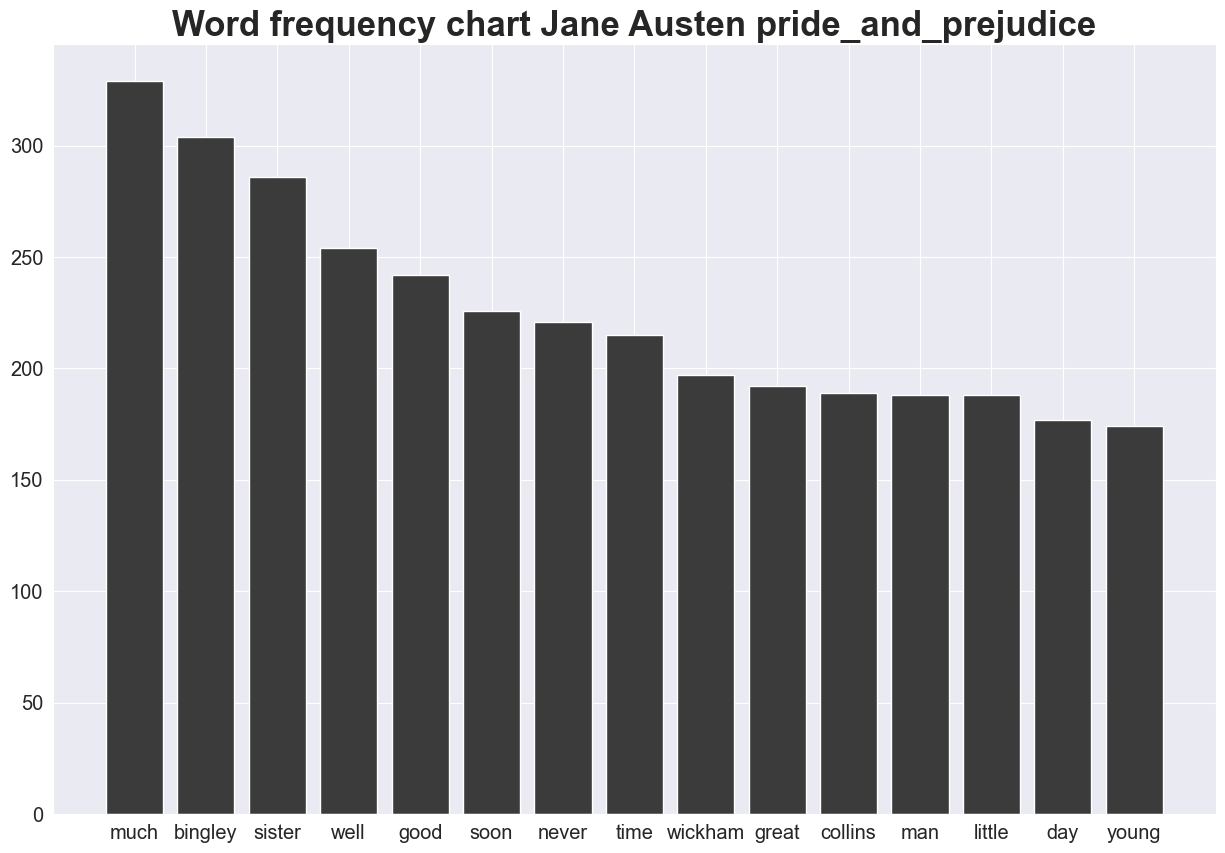

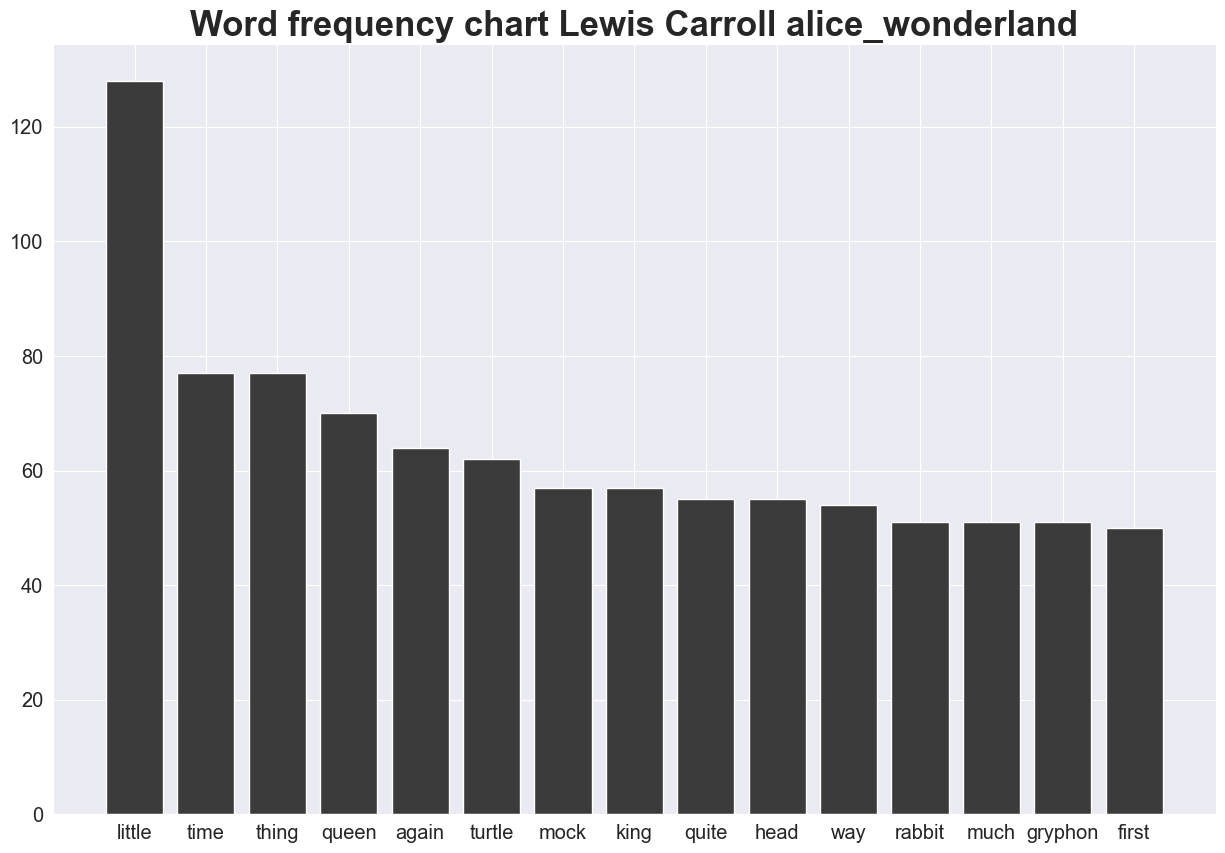

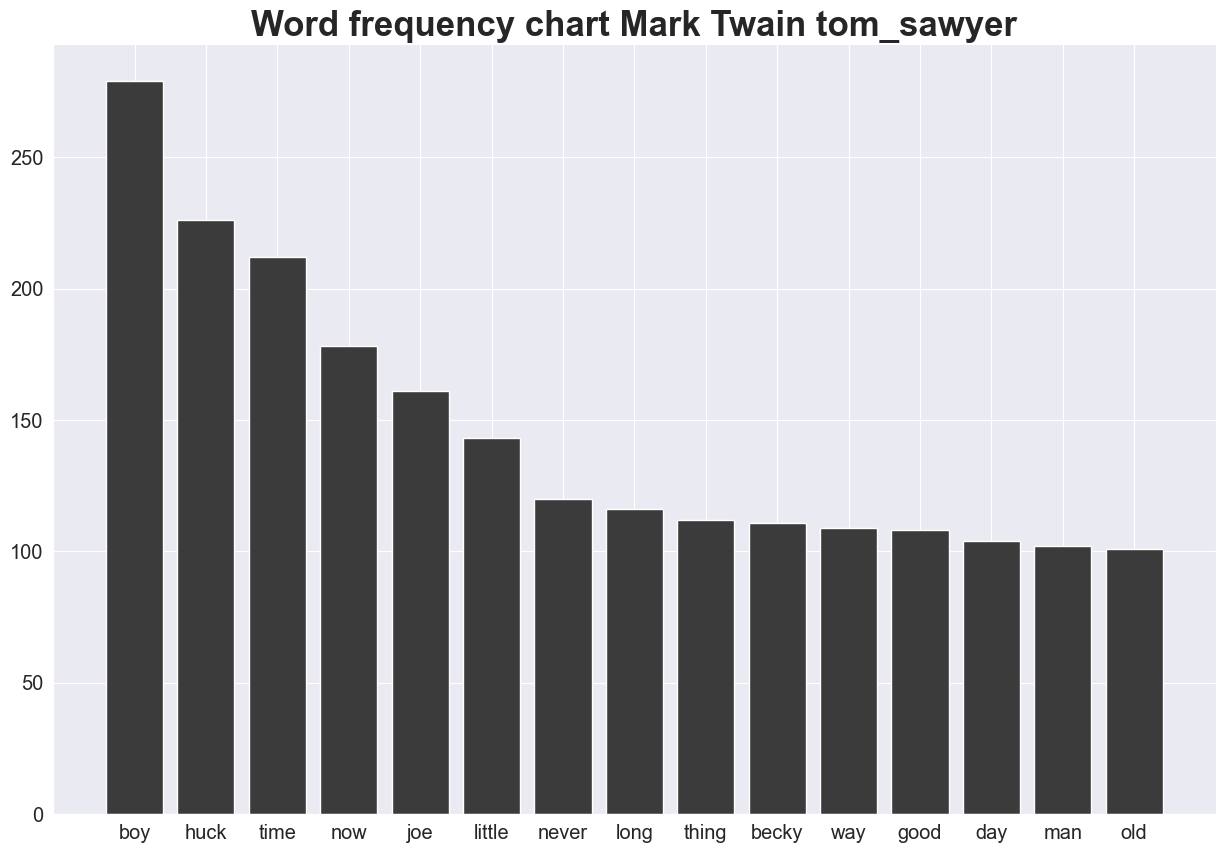

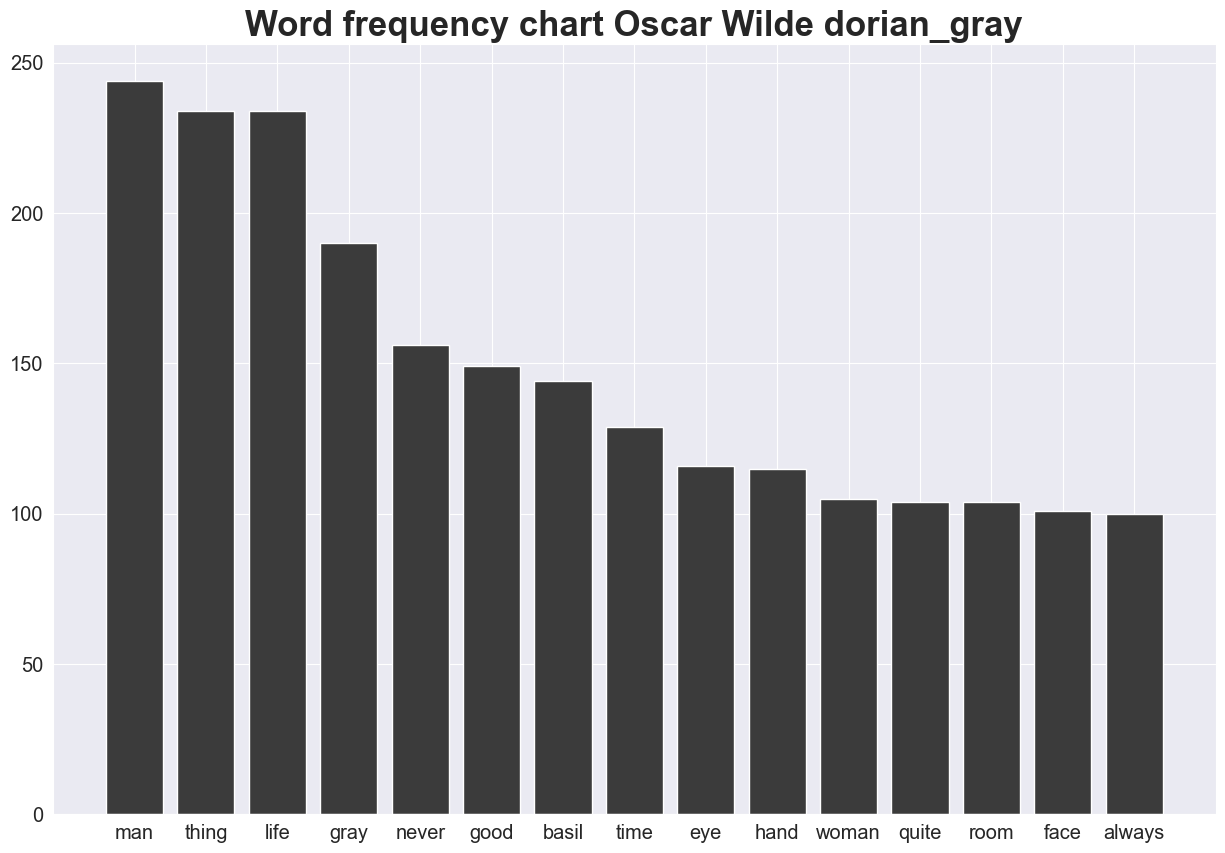

In [25]:
import itertools
import seaborn as sns
import matplotlib.pyplot as plt
corpus_tokenized = {}
for name_corpus, details in initial_clean.items():
    text = details["text"]
    author = details["author"]
    #completed_text = " ".join(text)
    text_preprocessed = process_text(text, min_tokens=2)
    text_normalized = normalize_tokens(text_preprocessed)
    text_processed = list(itertools.chain.from_iterable(text_normalized))
    word_not_count = ['alice', 'tom', 'elizabeth', 'dorian', 'darcy', 'bennet', 'jane', 'henry', 'harry']
    filtered_words = [word for word in text_processed if word.lower() not in word_not_count]
    word_frequency = Counter(filtered_words)
    corpus_tokenized[name_corpus] = {
        "author" : author,
        "book_name": details["book_title"],
        "sentences_tokens": text_normalized,
        "sentences": text_processed,
        "word_frequency": word_frequency
    }
    sns.set_style('darkgrid')
    fig = plt.subplots(figsize=(15, 10))
    plt.bar(x=[x[0] for x in word_frequency.most_common(15)], height=[x[1] for x in word_frequency.most_common(15)], color='#3B3B3B')
    plt.title(f"Word frequency chart {name_corpus}", size=25, fontweight='bold')
    plt.xticks(size='x-large')
    plt.yticks(size='x-large')
    plt.show()

In [26]:
def count_tokens(processed_sentences):
    return sum(len(s) for s in processed_sentences)

In [27]:
for _, properties in corpus_tokenized.items():
    name = properties["book_name"]
    print(f"Corpus name: {name}")
    word_freq = properties['word_frequency']
    num_tokens = count_tokens(properties['sentences_tokens']) 
    print(f"Sentences token: {num_tokens}")
    for word, count in word_freq.items():
        if count > 200:
            print(f"Word '{word}' occurs {count} times")
    print("-----------")       

Corpus name: pride_and_prejudice
Sentences token: 36126
Word 'well' occurs 254 times
Word 'much' occurs 329 times
Word 'good' occurs 242 times
Word 'time' occurs 215 times
Word 'bingley' occurs 304 times
Word 'never' occurs 221 times
Word 'soon' occurs 226 times
Word 'sister' occurs 286 times
-----------
Corpus name: alice_wonderland
Sentences token: 7434
-----------
Corpus name: tom_sawyer
Sentences token: 22434
Word 'boy' occurs 279 times
Word 'huck' occurs 226 times
Word 'time' occurs 212 times
-----------
Corpus name: dorian_gray
Sentences token: 22847
Word 'thing' occurs 234 times
Word 'life' occurs 234 times
Word 'man' occurs 244 times
-----------


In [28]:
print(text_processed[:10])

['picture', 'dorian', 'gray', 'oscar', 'wilde', 'contents', 'preface', 'chapter', 'i', 'chapter']


In [29]:
import itertools
from sklearn.feature_extraction.text import TfidfVectorizer

def find_shared_tfidf_words(tokenized_corpora, top_n=50):
    """
    Find words with highest TF-IDF scores that appear in all corpora.
    """
    # Convert each corpus (list of tokenized sentences) to one big string
    corpus_texts = [' '.join(itertools.chain.from_iterable(docs)) for docs in tokenized_corpora]

    #print("Corpus texts:", corpus_texts)  # DEBUG: check not empty

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(corpus_texts)
    feature_names = vectorizer.get_feature_names_out()

    shared_words = set(feature_names)
    for i in range(len(tokenized_corpora)):
        present_words = set(feature_names[tfidf_matrix[i].nonzero()[1]])
        shared_words.intersection_update(present_words)

    word_scores = {
        word: sum(tfidf_matrix[i, vectorizer.vocabulary_[word]] for i in range(len(tokenized_corpora)))
        for word in shared_words
    }

    return dict(sorted(word_scores.items(), key=lambda x: -x[1])[:top_n])


In [30]:
def clean_tfidf_result(word_scores, decimals=2):
    clean_scores = {w: round(float(s), decimals) for w, s in word_scores.items()}
    return dict(sorted(clean_scores.items(), key=lambda x: -x[1]))


In [31]:
import json
most_common_word = {}
corpus_list = []
corpus_list_record = []
path_to_save = "outputs/"
filename =  "corpus_list.json"
for name, properties in corpus_tokenized.items():
    corpus = properties['sentences_tokens']
    author = properties['author']
    book_name = properties['book_name']
    corpus_record = {
        "book_name": book_name,
        "author": author,
        "sentences_tokens": corpus
    }
    corpus_list_record.append(corpus)
    corpus_list.append(corpus_record)

    os.makedirs(path_to_save, exist_ok=True)
    corpus_path = os.path.join(path_to_save, filename)

    with open(corpus_path, 'w', encoding='utf-8') as f:
        json.dump(corpus_list, f, ensure_ascii=False, indent=2)
    score_word = find_shared_tfidf_words(corpus_list_record, top_n=100)
    most_common_word = clean_tfidf_result(score_word)

In [32]:
print(most_common_word)

{'time': 0.43, 'little': 0.41, 'thing': 0.37, 'never': 0.35, 'man': 0.33, 'good': 0.33, 'much': 0.31, 'well': 0.28, 'day': 0.26, 'long': 0.25, 'great': 0.24, 'life': 0.24, 'way': 0.23, 'again': 0.22, 'now': 0.22, 'eye': 0.21, 'boy': 0.21, 'ever': 0.2, 'quite': 0.2, 'hand': 0.2, 'first': 0.19, 'moment': 0.19, 'always': 0.19, 'away': 0.18, 'room': 0.18, 'soon': 0.18, 'last': 0.18, 'head': 0.17, 'house': 0.17, 'back': 0.17, 'young': 0.16, 'dear': 0.16, 'face': 0.16, 'night': 0.15, 'old': 0.15, 'chapter': 0.15, 'sister': 0.15, 'so': 0.14, 'door': 0.14, 'word': 0.14, 'right': 0.14, 'voice': 0.14, 'world': 0.13, 'people': 0.13, 'really': 0.13, 'even': 0.13, 'friend': 0.13, 'round': 0.13, 'woman': 0.13, 'other': 0.13, 'many': 0.12, 'enough': 0.12, 'still': 0.12, 'place': 0.12, 'girl': 0.11, 'next': 0.11, 'course': 0.11, 'however': 0.11, 'then': 0.11, 'poor': 0.11, 'half': 0.11, 'here': 0.11, 'white': 0.11, 'sure': 0.11, 'far': 0.1, 'whole': 0.1, 'there': 0.1, 'rather': 0.1, 'large': 0.1, 'min

In [33]:
import json
most_common_token = {}
corpus_list_token = []
corpus_record_token = []

path_to_save = "outputs/"
filename =  "corpus_list_token.json"
for name, properties in corpus_tokenized.items():
    corpus_token = [properties['sentences']]
    book_name = properties['book_name']
    corpus_metadata_token = {
        "book_name": book_name,
        "author": author,
        "sentences_tokens": corpus
    }
    corpus_record_token.append(corpus_metadata_token)
    corpus_list_token.append(corpus_token)

    os.makedirs(path_to_save, exist_ok=True)
    corpus_path_token = os.path.join(path_to_save, filename)

    with open(corpus_path_token, 'w', encoding='utf-8') as f:
        json.dump(corpus_record_token, f, ensure_ascii=False, indent=2)
    score_token = find_shared_tfidf_words(corpus_list_token, top_n=100)
    most_common_token = clean_tfidf_result(score_token)

In [34]:
print(most_common_token)

{'time': 0.43, 'little': 0.41, 'thing': 0.37, 'never': 0.35, 'man': 0.33, 'good': 0.33, 'much': 0.31, 'well': 0.28, 'day': 0.26, 'long': 0.25, 'great': 0.24, 'life': 0.24, 'way': 0.23, 'again': 0.22, 'now': 0.22, 'eye': 0.21, 'boy': 0.21, 'ever': 0.2, 'quite': 0.2, 'hand': 0.2, 'first': 0.19, 'moment': 0.19, 'always': 0.19, 'away': 0.18, 'room': 0.18, 'soon': 0.18, 'last': 0.18, 'head': 0.17, 'house': 0.17, 'back': 0.17, 'young': 0.16, 'dear': 0.16, 'face': 0.16, 'night': 0.15, 'old': 0.15, 'chapter': 0.15, 'sister': 0.15, 'so': 0.14, 'door': 0.14, 'word': 0.14, 'right': 0.14, 'voice': 0.14, 'world': 0.13, 'people': 0.13, 'really': 0.13, 'even': 0.13, 'friend': 0.13, 'round': 0.13, 'woman': 0.13, 'other': 0.13, 'many': 0.12, 'enough': 0.12, 'still': 0.12, 'place': 0.12, 'girl': 0.11, 'next': 0.11, 'course': 0.11, 'however': 0.11, 'then': 0.11, 'poor': 0.11, 'half': 0.11, 'here': 0.11, 'white': 0.11, 'sure': 0.11, 'far': 0.1, 'whole': 0.1, 'there': 0.1, 'rather': 0.1, 'large': 0.1, 'min

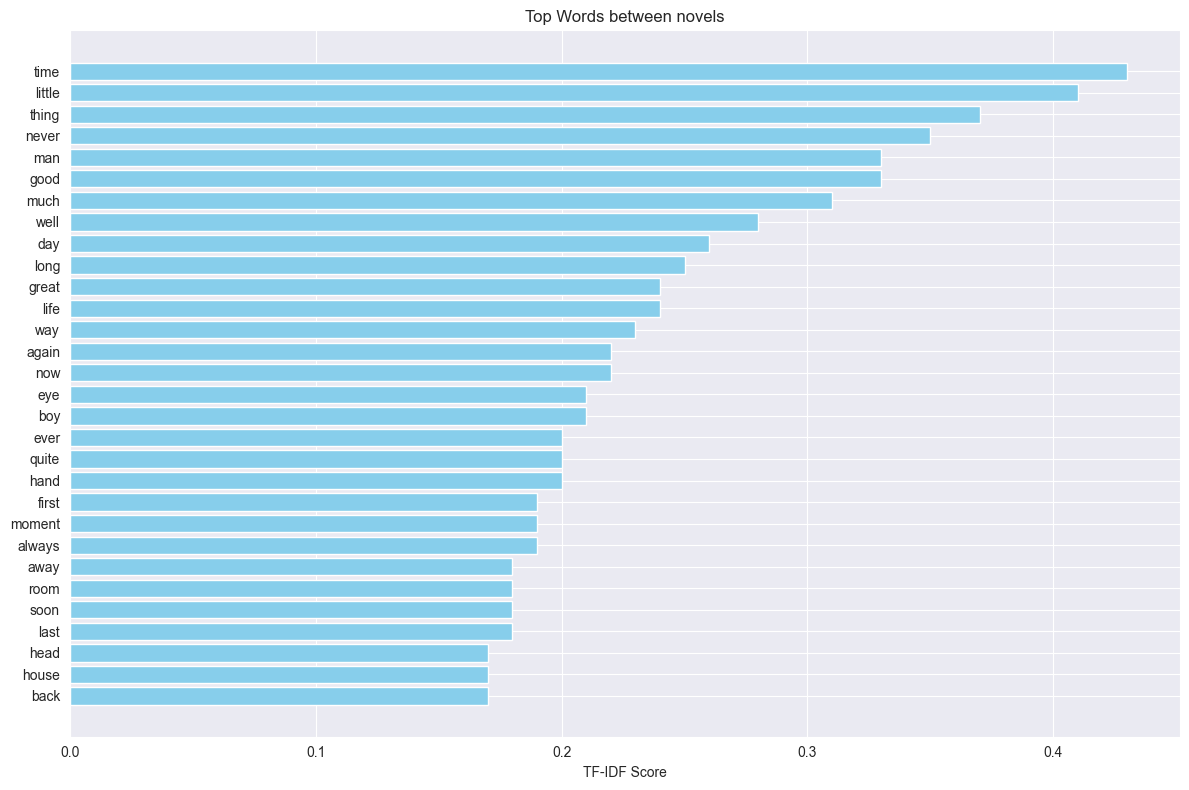

In [35]:
# Sort and limit
sorted_items = sorted(most_common_token.items(), key=lambda x: -x[1])[:30]

# Prepare lists
words = [item[0] for item in sorted_items]
scores = [item[1] for item in sorted_items]

plt.figure(figsize=(12, 8))
plt.barh(words, scores, color='skyblue')
plt.xlabel("TF-IDF Score")
plt.title("Top Words between novels")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()